# Study 780 — Long-Weekend-Drift 🏖️

*For the curious.* Traders have said for a century that the market drifts up into a holiday — buy the day before a long weekend. We put **192 US market holidays** (2005→2025) on the stand and asked the tape one plain question: **does SPY beat an ordinary day on the pre-holiday session?** The answer: a faint yes that dies the moment you pay a spread.

## The claim, and why it's a clean test

The NYSE holiday schedule is **published years ahead**, so *buy K sessions before the holiday, sell on the eve close* is calendar-known and zero-look-ahead. SPY is tested on its own, so **'abnormal' means excess over SPY's own average day** — does the holiday-eve session beat a normal session, not another asset.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from long_weekend_drift import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} holidays resolved")


panel loaded; 192 of 192 holidays resolved


## The holiday calendar we test (hardcoded from the NYSE schedule)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['holiday_date', 'name']).tail(12)

,holiday_date,name
180,2024-11-28,Thanksgiving
181,2024-12-25,Christmas
182,2025-01-01,NewYears
183,2025-01-20,MLK
184,2025-02-17,Presidents
185,2025-04-18,GoodFriday
186,2025-05-26,Memorial
187,2025-06-19,Juneteenth
188,2025-07-04,Independence
189,2025-09-01,Labor


## The picture: mean cumulative excess return around the holiday-eve

Offset 0 is the holiday-eve close. Left of zero leads *into* the holiday (the supposed run-up); right of zero is the post-holiday sessions.

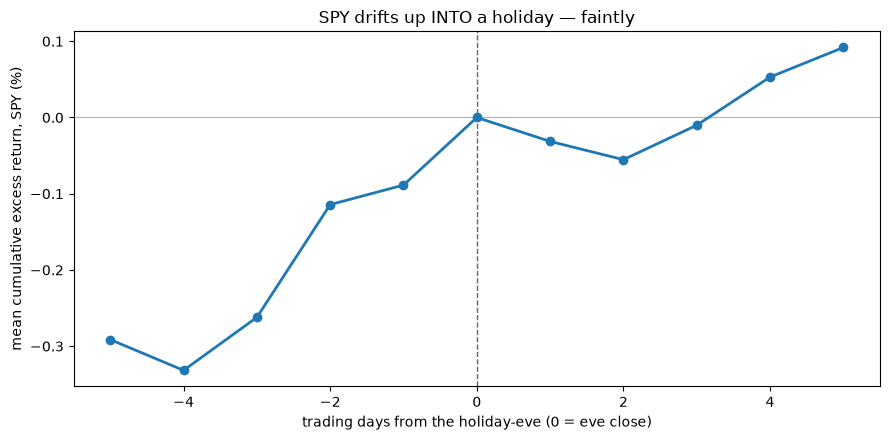

In [3]:
car = st.car_path(ev, prices, pre=5, post=5)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#1f77b4', lw=2, marker='o')
ax.set_xlabel('trading days from the holiday-eve (0 = eve close)')
ax.set_ylabel('mean cumulative excess return, SPY (%)')
ax.set_title('SPY drifts up INTO a holiday — faintly')
plt.tight_layout(); plt.show()

## The numbers

| window | mean excess | *t* | hit rate |
|---|--:|--:|--:|
| holiday-eve (pre1) | **+0.10%** | **+1.53** | 112/192 |
| 3-session run-up (pre3) | +0.30% | +2.19 | 113/192 |
| post-holiday (post1) | -0.03% | -0.38 | 90/192 |

The folklore's **direction is there** — the eve beats an ordinary day by 0.10% and the 3-session run-up by 0.30%, both with ~58% up-days. But the classic single-eve cut is **not significant** (*t* = +1.53); only the wider run-up crosses the line (*t* = +2.19). And the day *after*? A clean zero.

In [4]:
rows = [('eve pre1','pre1'),('run-up pre3','pre3'),('post1','post1')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<12s} n={s["n"]:3d}  mean={s["mean"]*100:+.4f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

eve pre1     n=192  mean=+0.0964%  t=+1.532  hit 112/192
run-up pre3  n=192  mean=+0.2986%  t=+2.195  hit 113/192
post1        n=192  mean=-0.0314%  t=-0.384  hit 90/192


## So what?

The famous *buy into the long weekend* trade is a **faint, cost-fragile echo** of the old pre-holiday anomaly: the drift is there in the right direction, but the classic single-day version is statistically unremarkable and a 5 bps round-trip zeroes it out. Verdict: **Weak signal, Fragile tradability.** The quants' notebook has the placebo, the jackknife, the decay split, the costed leg and the synthetic control.